In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
 
# ARIMA and statistical tests
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
 
# Machine learning
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor
 
# Plot styling
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['font.size'] = 11
 
print("All libraries imported successfully.")
print(f"   pandas      : {pd.__version__}")
print(f"   numpy       : {np.__version__}")
print(f"   scikit-learn:  imported")
print(f"   xgboost     :  imported")
 


All libraries imported successfully.
   pandas      : 2.2.3
   numpy       : 2.2.2
   scikit-learn:  imported
   xgboost     :  imported


In [29]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns 

df = pd.read_csv("household_power_consumption.txt",
    sep=";",
    low_memory=False,
    na_values='?' 
)

print(df.head()) 
print(df.columns) 


         Date      Time  Global_active_power  Global_reactive_power  Voltage  \
0  16/12/2006  17:24:00                4.216                  0.418   234.84   
1  16/12/2006  17:25:00                5.360                  0.436   233.63   
2  16/12/2006  17:26:00                5.374                  0.498   233.29   
3  16/12/2006  17:27:00                5.388                  0.502   233.74   
4  16/12/2006  17:28:00                3.666                  0.528   235.68   

   Global_intensity  Sub_metering_1  Sub_metering_2  Sub_metering_3  
0              18.4             0.0             1.0            17.0  
1              23.0             0.0             1.0            16.0  
2              23.0             0.0             2.0            17.0  
3              23.0             0.0             1.0            17.0  
4              15.8             0.0             1.0            17.0  
Index(['Date', 'Time', 'Global_active_power', 'Global_reactive_power',
       'Voltage', 'Global_in

In [30]:
print(df.isnull().sum())

Date                         0
Time                         0
Global_active_power      25979
Global_reactive_power    25979
Voltage                  25979
Global_intensity         25979
Sub_metering_1           25979
Sub_metering_2           25979
Sub_metering_3           25979
dtype: int64


In [31]:
#dataset shape
print("=" * 55 )
print("=" * 55)

print("\n Shape (rows x columns):")
print(df.shape)

print("\n Column names:")
print(list(df.columns))


print("\n Data types:")
print(df.dtypes)


print("\n Missing values per column:")
print(df.isnull().sum())



print("\n First 5 rows of raw data:")
print(df.head())



 Shape (rows x columns):
(2075259, 9)

 Column names:
['Date', 'Time', 'Global_active_power', 'Global_reactive_power', 'Voltage', 'Global_intensity', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3']

 Data types:
Date                      object
Time                      object
Global_active_power      float64
Global_reactive_power    float64
Voltage                  float64
Global_intensity         float64
Sub_metering_1           float64
Sub_metering_2           float64
Sub_metering_3           float64
dtype: object

 Missing values per column:
Date                         0
Time                         0
Global_active_power      25979
Global_reactive_power    25979
Voltage                  25979
Global_intensity         25979
Sub_metering_1           25979
Sub_metering_2           25979
Sub_metering_3           25979
dtype: int64

 First 5 rows of raw data:
         Date      Time  Global_active_power  Global_reactive_power  Voltage  \
0  16/12/2006  17:24:00                4.

In [32]:
#4. Create Datetime column from Date and Time Index
df['Datetime'] = pd.to_datetime(
    df['Date'] + ' ' + df['Time'],
    dayfirst=True
)

df.drop(columns=['Date', 'Time'], inplace=True)
df.set_index('Datetime' , inplace=True)
df.sort_index(inplace=True)

#convert all columns from text to numbers

for col in df.columns:
      df[col] = pd.to_numeric(df[col], errors='coerce')
    
print(" Datetime index created succcessfully.") 
print(f"\n Date range: {df.index.min()} - {df.index.max()}")
print(f"\n First 5 rows with datetime index:")
print(df.head())
    

 Datetime index created succcessfully.

 Date range: 2006-12-16 17:24:00 - 2010-11-26 21:02:00

 First 5 rows with datetime index:
                     Global_active_power  Global_reactive_power  Voltage  \
Datetime                                                                   
2006-12-16 17:24:00                4.216                  0.418   234.84   
2006-12-16 17:25:00                5.360                  0.436   233.63   
2006-12-16 17:26:00                5.374                  0.498   233.29   
2006-12-16 17:27:00                5.388                  0.502   233.74   
2006-12-16 17:28:00                3.666                  0.528   235.68   

                     Global_intensity  Sub_metering_1  Sub_metering_2  \
Datetime                                                                
2006-12-16 17:24:00              18.4             0.0             1.0   
2006-12-16 17:25:00              23.0             0.0             1.0   
2006-12-16 17:26:00              23.0       

In [33]:
#5. Covert minute data to hourly averages 

hourly_df = df.resample("h").mean(numeric_only=True)

print("Hourly Dataset Created")

print("\nShape;")
print(hourly_df.shape)

print("\nfirst 5 Rows:")
print(hourly_df.head())



Hourly Dataset Created

Shape;
(34589, 7)

first 5 Rows:
                     Global_active_power  Global_reactive_power     Voltage  \
Datetime                                                                      
2006-12-16 17:00:00             4.222889               0.229000  234.643889   
2006-12-16 18:00:00             3.632200               0.080033  234.580167   
2006-12-16 19:00:00             3.400233               0.085233  233.232500   
2006-12-16 20:00:00             3.268567               0.075100  234.071500   
2006-12-16 21:00:00             3.056467               0.076667  237.158667   

                     Global_intensity  Sub_metering_1  Sub_metering_2  \
Datetime                                                                
2006-12-16 17:00:00         18.100000             0.0        0.527778   
2006-12-16 18:00:00         15.600000             0.0        6.716667   
2006-12-16 19:00:00         14.503333             0.0        1.433333   
2006-12-16 20:00:00     

In [34]:
#6. Handle Missing Values 
print("Missing values Before cleaning:")
print(hourly_df.isnull().sum())
total_missing = hourly_df['Global_active_power'].isnull().sum()
print(f"\n Total missing in target column: {total_missing:,}")

#Apply linear interpolation (estimates smooth values between gaps)
hourly_df = hourly_df.interpolate(method='linear')

#Catch any edge NaNs at very start or end of the series 
hourly_df = hourly_df.ffill().bfill()

print("\n Missing values AFTER cleaning:")
print(hourly_df.isnull().sum())
print("\n Missing values handled using linear interpolation.")




Missing values Before cleaning:
Global_active_power      421
Global_reactive_power    421
Voltage                  421
Global_intensity         421
Sub_metering_1           421
Sub_metering_2           421
Sub_metering_3           421
dtype: int64

 Total missing in target column: 421

 Missing values AFTER cleaning:
Global_active_power      0
Global_reactive_power    0
Voltage                  0
Global_intensity         0
Sub_metering_1           0
Sub_metering_2           0
Sub_metering_3           0
dtype: int64

 Missing values handled using linear interpolation.


In [35]:
#Cell 7 Feature Engineering 

series = hourly_df['Global_active_power'].copy()
ml_df = pd.DataFrame({'target': series})

#time features

ml_df['hour']   = ml_df.index.hour
ml_df['day_of_week'] = ml_df.index.dayofweek    #0=Monday. 6=Sunday 
ml_df['month'] = ml_df.index.month    
ml_df['quarter'] = ml_df.index.quarter   
ml_df['is_weekend'] = (ml_df.index.dayofweek >= 5).astype(int)

#Lag features
ml_df['lag_1']  =ml_df['target'].shift(1)
ml_df['lag_24']  =ml_df['target'].shift(24)
ml_df['lag_168'] =ml_df['target'].shift(168)


#Rolling features (24 hrs window) 
ml_df['rolling_mean_24'] = ml_df['target'].rolling(24).mean()
ml_df['rolling_std_24'] = ml_df['target'].rolling(24).std()

#Drop rows with NaN from lag/rolling (first 168 rows) 
ml_df.dropna(inplace=True)

print("Features created successfully.")
print(f"features dataset shape: {ml_df.shape}")
print(f"features columns: {list(ml_df.columns)}")
print(f"First 3 rows:")
print(ml_df.head(3)) 


Features created successfully.
features dataset shape: (34421, 11)
features columns: ['target', 'hour', 'day_of_week', 'month', 'quarter', 'is_weekend', 'lag_1', 'lag_24', 'lag_168', 'rolling_mean_24', 'rolling_std_24']
First 3 rows:
                       target  hour  day_of_week  month  quarter  is_weekend  \
Datetime                                                                       
2006-12-23 17:00:00  5.452533    17            5     12        4           1   
2006-12-23 18:00:00  3.879400    18            5     12        4           1   
2006-12-23 19:00:00  4.117833    19            5     12        4           1   

                        lag_1    lag_24   lag_168  rolling_mean_24  \
Datetime                                                             
2006-12-23 17:00:00  4.349100  1.496800  4.222889         3.099713   
2006-12-23 18:00:00  5.452533  2.686967  3.632200         3.149397   
2006-12-23 19:00:00  3.879400  3.938167  3.400233         3.156883   

              

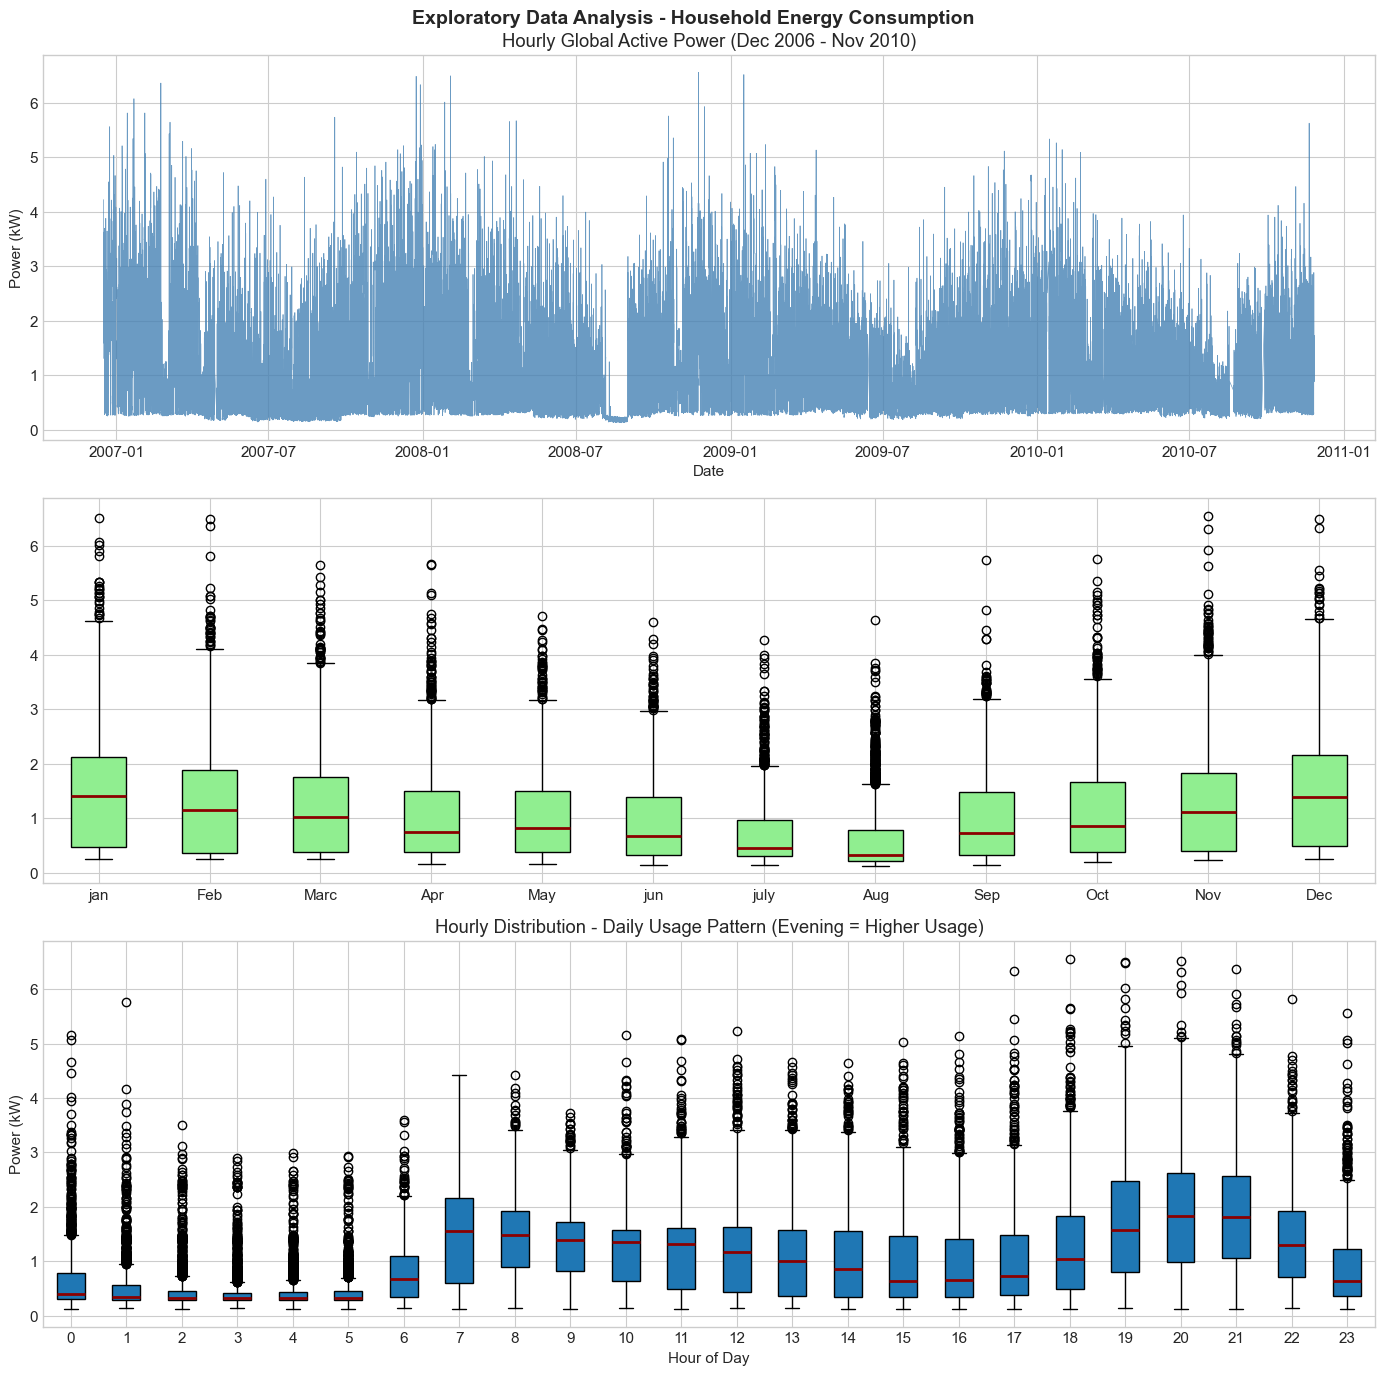

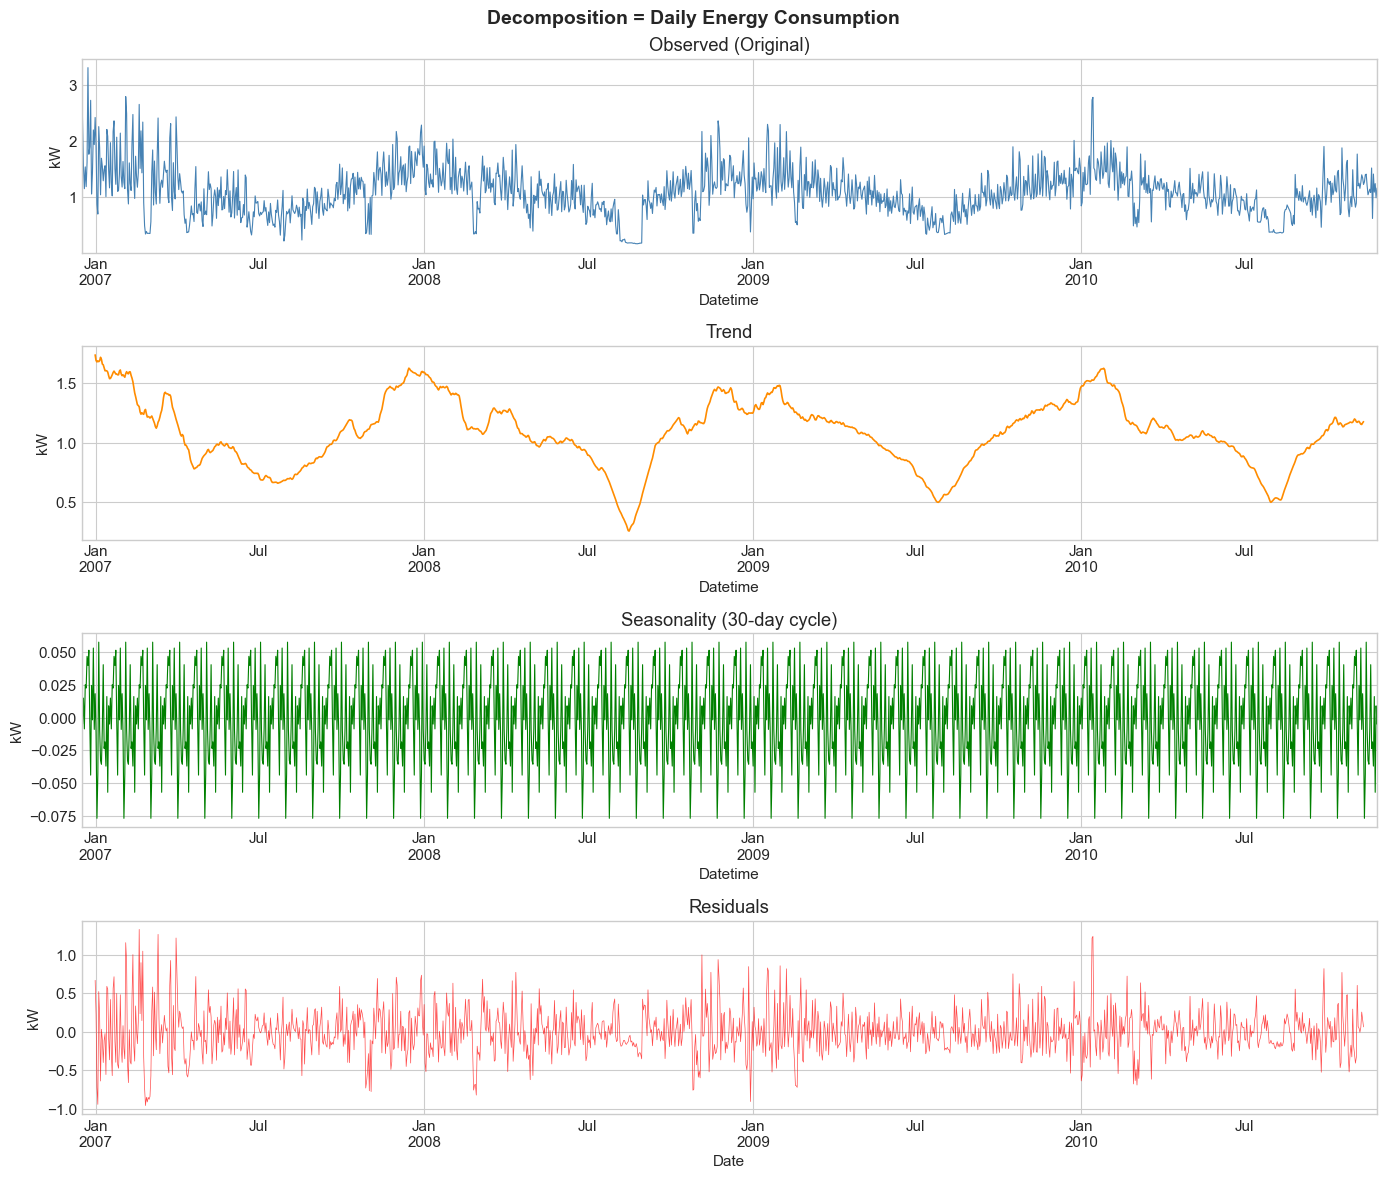


 Summary statistics of hourly power consumption:
count    34589.0000
mean         1.0925
std          0.8957
min          0.1240
25%          0.3434
50%          0.8068
75%          1.5782
max          6.5605
Name: Global_active_power, dtype: float64


In [36]:
#8. EDA Graphics

fig, axes = plt.subplots(3,1, figsize=(14,14))
fig.suptitle('Exploratory Data Analysis - Household Energy Consumption',
             fontsize=14, fontweight='bold')

# A: Full time Series 

axes[0].plot(series.index,series.values, color='steelblue', linewidth=0.5 , alpha= 0.8)

axes[0].set_title('Hourly Global Active Power (Dec 2006 - Nov 2010)')
axes[0].set_ylabel('Power (kW)')
axes[0].set_xlabel('Date')

# B: Monthly box plot 

month_data = [series[series.index.month ==m].values for m in range(1,13)] 
months = ['jan','Feb','Marc','Apr','May','jun','july','Aug','Sep','Oct','Nov','Dec']
bp = axes[1].boxplot(month_data, labels=months, patch_artist=True,
                     medianprops=dict(color='darkred', linewidth=2))

for patch in bp['boxes']:
    patch.set_facecolor('lightgreen')
axes[2].set_title('Monthly Distribution - Daily Usage Pattern (Evening = Higher Usage)')
axes[2].set_ylabel('Power (kW)')
axes[2].set_xlabel('Month')

#C : Hourly 
hour_data = [series[series.index.hour == h].values for h in range(0, 24)]
axes[2].boxplot(hour_data, labels=range(0, 24), patch_artist=True,
                medianprops=dict(color='darkred', linewidth=2))
axes[2].set_title('Hourly Distribution - Daily Usage Pattern (Evening = Higher Usage)')
axes[2].set_ylabel('Power (kW)')
axes[2].set_xlabel('Hour of Day')

plt.tight_layout()
plt.savefig('eda_pattterns.png', dpi=150, bbox_inches='tight')
plt.show()



#Graph D : Decomposition 
daily_for_decomp = series.resample('D').mean().dropna()

decomp= seasonal_decompose(daily_for_decomp, model='additive', period=30) 

fig2, axes2 = plt.subplots(4,1,figsize=(14,12)) 
fig2.suptitle('Decomposition = Daily Energy Consumption', fontsize=14, fontweight='bold')

decomp.observed.plot(ax=axes2[0] , color='steelblue', linewidth=0.8)
axes2[0].set_title('Observed (Original)'); axes2[0].set_ylabel('kW')


decomp.trend.plot(ax=axes2[1] , color='darkorange', linewidth=1.2)
axes2[1].set_title('Trend'); axes2[1].set_ylabel('kW')

decomp.seasonal.plot(ax=axes2[2], color = 'green', linewidth=0.8)
axes2[2].set_title('Seasonality (30-day cycle)'); axes2[2].set_ylabel('kW')

decomp.resid.plot(ax=axes2[3] , color='red', linewidth=0.5 , alpha= 0.7)
axes2[3].set_title('Residuals'); axes2[3].set_ylabel('kW')
axes2[3].set_xlabel('Date')

plt.tight_layout()
plt.savefig('seasonal_Decomposition', dpi=150 , bbox_inches='tight')
plt.show()
print("\n Summary statistics of hourly power consumption:")
print(series.describe().round(4))



Train / test split

 ARIMA Train: 2006-12-16 -> 2010-02-11
ARIMA Test: 2010-02-11 -> 2010-11-26

ML Train: 27,536 rows
ML Test: 6,885 rows
 Split visualization


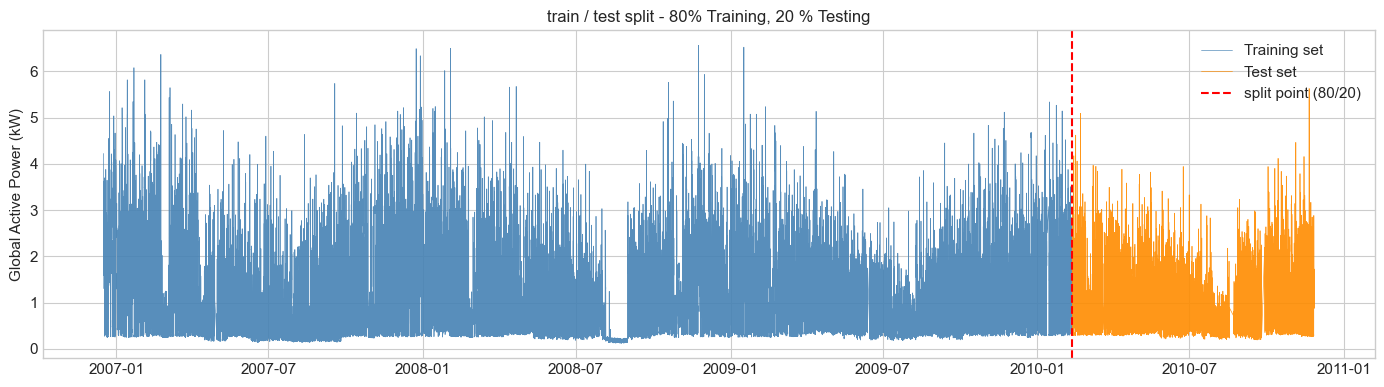

In [37]:
#9 Train / test Split 

split_point =int(len(series) * 0.80)
train_arima = series.iloc[:split_point]
test_arima = series.iloc[split_point:]

#split for Random forest and XGBoost (feature matrix) 
 
feature_cols = [c for c in ml_df.columns if c !='target']
split_ml = int(len(ml_df) * 0.80)
X_train = ml_df[feature_cols].iloc[:split_ml] 
y_train = ml_df['target'].iloc[:split_ml]
X_test = ml_df[feature_cols].iloc[split_ml:]
y_test = ml_df['target'].iloc[split_ml:]

print("=" * 55)
print("Train / test split")
print("=" * 55)
print(f"\n ARIMA Train: {train_arima.index[0].date()} -> {train_arima.index[-1].date()}")
print(f"ARIMA Test: {test_arima.index[0].date()} -> {test_arima.index[-1].date()}")
print(f"\nML Train: {len(X_train):,} rows")
print(f"ML Test: {len(X_test):,} rows")


#Visulaise the split 
fig, ax = plt.subplots(figsize=(14,4))
ax.plot(train_arima.index, train_arima.values,label='Training set',
          color='steelblue', linewidth=0.5, alpha=0.9)
ax.plot(test_arima.index, test_arima.values, label='Test set',
        color='darkorange', linewidth=0.5, alpha=0.9)
ax.axvline(x=test_arima.index[0],color='red', linestyle='--',
           linewidth=1.5, label='split point (80/20)')
ax.set_title('train / test split - 80% Training, 20 % Testing', fontsize=12)
ax.set_ylabel('Global Active Power (kW)')
ax.legend()
plt.tight_layout()

print(" Split visualization") 
            



MODEL 1: ARIMA

Step 1: Augmented Dickey-Fuller (ADF) Stationarity Test
--------------------------------------------------
ADF Statistic : -6.6741
p-value       : 0.0000
Series IS stationary (p < 0.05) → using d=0


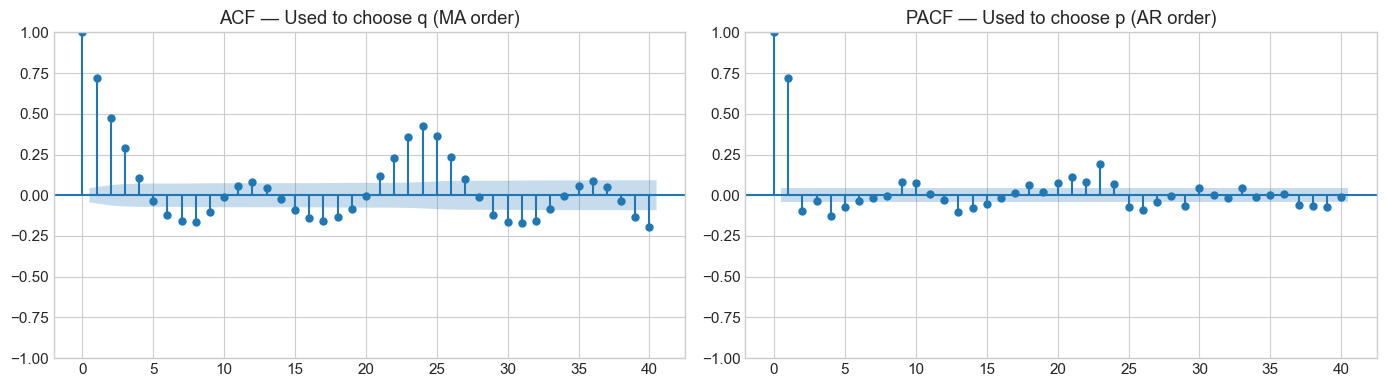


Step 2 : Fitting ARIMA(2, 0, 0)...

ARIMA training complete.
   MAE  = 0.7145 kW
   RMSE = 0.8937 kW
   R²   = -0.0048


In [38]:
#10 Arima 
print("=" * 55)
print("MODEL 1: ARIMA")
print("=" * 55)
 
#  ARIMA Sample  
n_arima = 2000
train_a = train_arima.iloc[-n_arima:]    # last 2000 training points
test_a  = test_arima.iloc[:200]          # first 200 test points
 
print("\nStep 1: Augmented Dickey-Fuller (ADF) Stationarity Test")
print("-" * 50)
adf_result = adfuller(train_a, autolag='AIC')
print(f"ADF Statistic : {adf_result[0]:.4f}")
print(f"p-value       : {adf_result[1]:.4f}")
 
if adf_result[1] < 0.05:
    print("Series IS stationary (p < 0.05) → using d=0")
    d_val = 0
else:
    print("Series NOT stationary (p > 0.05) → using d=1 (differencing)")
    d_val = 1
 
# ACF and PACF plots to visually choose p and q
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(train_a, lags=40, ax=axes[0])
axes[0].set_title('ACF — Used to choose q (MA order)')
plot_pacf(train_a, lags=40, ax=axes[1])
axes[1].set_title('PACF — Used to choose p (AR order)')
plt.tight_layout()
plt.savefig('acf_pacf', dpi=150, bbox_inches='tight')
plt.show()
 # for Screenshot in project
 
arima_order = (2,d_val,0)
arima_label = f'ARIMA{arima_order}'
print(f"\nStep 2 : Fitting {arima_label}...") 


model_arima = ARIMA(train_a, order=(2, d_val, 0))
arima_fit   = model_arima.fit()
pred_arima  = pd.Series(
    arima_fit.forecast(steps=len(test_a)).values,
    index=test_a.index
)
 
mae_arima  = mean_absolute_error(test_a, pred_arima)
rmse_arima = np.sqrt(mean_squared_error(test_a, pred_arima))
r2_arima   = r2_score(test_a, pred_arima)
 
print("\nARIMA training complete.")
print(f"   MAE  = {mae_arima:.4f} kW")
print(f"   RMSE = {rmse_arima:.4f} kW")
print(f"   R²   = {r2_arima:.4f}")

In [39]:
#11 Random Forest Model 


print("=" * 55) 
print("Random Forest")
print("=" * 55) 


rf_model = RandomForestRegressor(
    n_estimators=200, 
    max_depth=10,
    min_samples_leaf=5,
    n_jobs= -1,
    random_state=42

)

rf_model.fit(X_train , y_train)
pred_rf = rf_model.predict(X_test)

mae_rf = mean_absolute_error(y_test,pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, pred_rf))
r2_rf = r2_score(y_test, pred_rf)

print("\n Random Forest training complete.")
print(f" MAE = {mae_rf:.4f}  kW")
print(f" RMSE = {rmse_rf:.4f}  kW")
print(f"    R*2    = {r2_rf:.4f}")


#Important Feature 

feat_imp = pd.Series(rf_model.feature_importances_, index=feature_cols).sort_values(ascending=False)
print(f"\nTop 5 important features:")
print(feat_imp.head(5).round(4))


Random Forest

 Random Forest training complete.
 MAE = 0.3230  kW
 RMSE = 0.4632  kW
    R*2    = 0.5943

Top 5 important features:
lag_1             0.7212
hour              0.0930
rolling_std_24    0.0562
lag_168           0.0543
lag_24            0.0314
dtype: float64


In [40]:
# 12 XGBoost Model 

print("=" * 55)
print("Model 3: XGBoost Regressor")
print("=" * 55)

xgb_model = XGBRegressor(
        max_depth=6,
         learning_rate = 0.05,
         n_estimators= 300,
        subsample=0.8,
        random_state=42,
        verbosity=0
)
xgb_model.fit(X_train, y_train)
pred_xgb = xgb_model.predict(X_test)

mae_xgb = mean_absolute_error(y_test,pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, pred_xgb))
r2_xgb   =  r2_score(y_test, pred_xgb)

print("\n XGBoost training complete.")
print(f" MAE = {mae_xgb:.4f} kW")
print(f" RMSE = {rmse_xgb:.4f} kW")
print(f" R2 = {r2_xgb:.4f}")


Model 3: XGBoost Regressor

 XGBoost training complete.
 MAE = 0.3191 kW
 RMSE = 0.4574 kW
 R2 = 0.6044


EVALUATION MATRIX - ALL Models
arima_label:
 MAE = 0.7145 kW
 RMSE = 0.8937 kW
 R2   = -0.0048
Random Forest:
 MAE = 0.3230 kW
 RMSE = 0.4632 kW
 R2   = 0.5943
XGBoost:
 MAE = 0.3191 kW
 RMSE = 0.4574 kW
 R2   = 0.6044


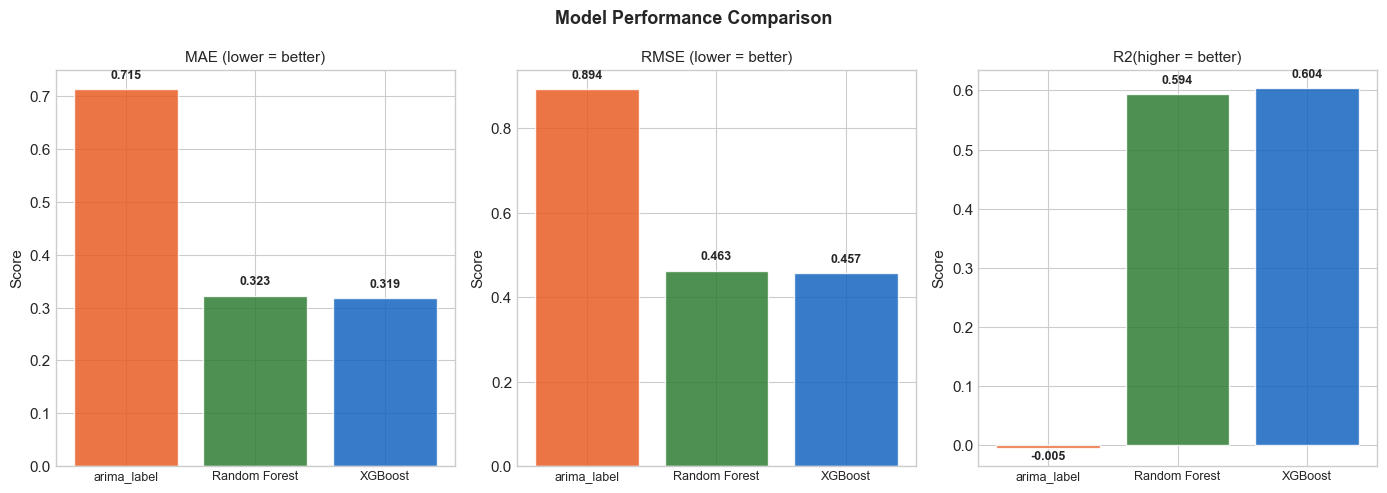

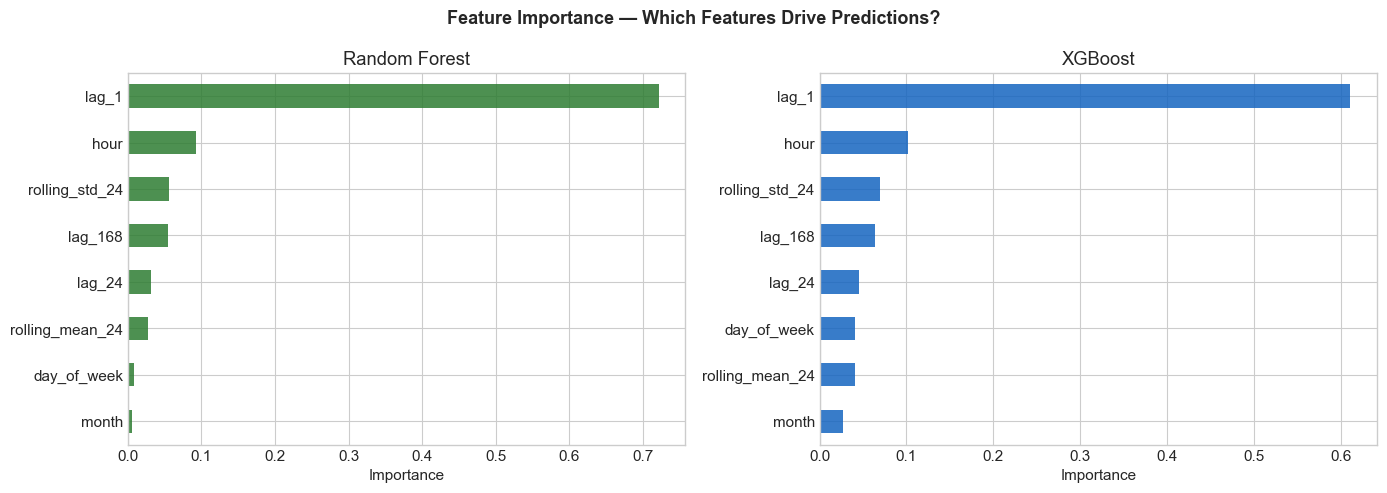

In [41]:
#13  Evaluation Matrix 

print("=" * 60)
print("EVALUATION MATRIX - ALL Models")
print("=" * 60)

models_list = ['arima_label', 'Random Forest', 'XGBoost']
mae_vals    = [mae_arima , mae_rf , mae_xgb]
rmse_vals   = [rmse_arima, rmse_rf , rmse_xgb]
r2_vals     = [r2_arima , r2_rf , r2_xgb]


for name,mae, rmse,r2 in zip(models_list,mae_vals,rmse_vals,r2_vals):
            print(f"{name}:")
            print(f" MAE = {mae:.4f} kW")
            print(f" RMSE = {rmse:.4f} kW")
            print(f" R2   = {r2:.4f}")

# Bar Chart Matrix 
fig, axes = plt.subplots(1,3,figsize=(14,5))
fig.suptitle('Model Performance Comparison', fontsize=13, fontweight='bold')


colors = ['#E85D24', '#2E7D32', '#1565C0']

for ax, values, metric in zip(
    axes, 
    [mae_vals,rmse_vals, r2_vals],
    ['MAE (lower = better)', 'RMSE (lower = better)','R2(higher = better)']):
  bars = ax.bar(models_list , values,color=colors, alpha=0.85 , edgecolor='white')  
  ax.set_title(metric,fontsize = 11)
  ax.set_ylabel('Score')
  ax.tick_params(axis='x', labelsize=9)
  for bar, val in zip(bars, values):
        offset = max(abs(v) for v in values) * 0.02
        y_pos  = bar.get_height() + offset if val >= 0 else bar.get_height() - offset * 2
        ax.text(bar.get_x() + bar.get_width() / 2,
                y_pos,
                f'{val:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
 
plt.tight_layout()
plt.savefig('metrics_comparison', dpi=150, bbox_inches='tight')
plt.show()

# Feature importance chart
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Feature Importance — Which Features Drive Predictions?',
             fontsize=13, fontweight='bold')
 
rf_imp_plot = pd.Series(rf_model.feature_importances_,
                        index=feature_cols).sort_values().tail(8)
rf_imp_plot.plot(kind='barh', ax=axes[0], color='#2E7D32', alpha=0.85)
axes[0].set_title('Random Forest')
axes[0].set_xlabel('Importance')
 
xgb_imp_plot = pd.Series(xgb_model.feature_importances_,
                          index=feature_cols).sort_values().tail(8)
xgb_imp_plot.plot(kind='barh', ax=axes[1], color='#1565C0', alpha=0.85)
axes[1].set_title('XGBoost')
axes[1].set_xlabel('Importance')
 
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()



In [42]:
#14 Comparison table 

print("=" * 60)
print("Final Model Comparison Table")
print("=" * 60)

results= pd.DataFrame({
    'Model'  : models_list,
    'MAE (kW)' : [round(v,4) for v in mae_vals],
    'RMSE (kW)' : [round(v,4) for v in rmse_vals],
    'R2'       : [round(v,4) for v in r2_vals]

})


print(results.to_string(index=False))

#Best model by R2 

best_idx  = results['R2'].idxmax()
best_model = results.loc[best_idx,'Model']
best_r2    =  results.loc[best_idx,'R2']
best_mae   =  results.loc[best_idx, 'MAE (kW)']

print(f"\nBest model: {best_model}")
print(f"   R²   = {best_r2}")
print(f"   MAE  = {best_mae} kW")
print(f"\n   Interpretation: {best_model} explains {best_r2*100:.1f}% of the")
print(f" energy consumption variance and prediction")
print(f"   {best_mae:.3f} kW on average.")

Final Model Comparison Table
        Model  MAE (kW)  RMSE (kW)      R2
  arima_label    0.7145     0.8937 -0.0048
Random Forest    0.3230     0.4632  0.5943
      XGBoost    0.3191     0.4574  0.6044

Best model: XGBoost
   R²   = 0.6044
   MAE  = 0.3191 kW

   Interpretation: XGBoost explains 60.4% of the
 energy consumption variance and prediction
   0.319 kW on average.


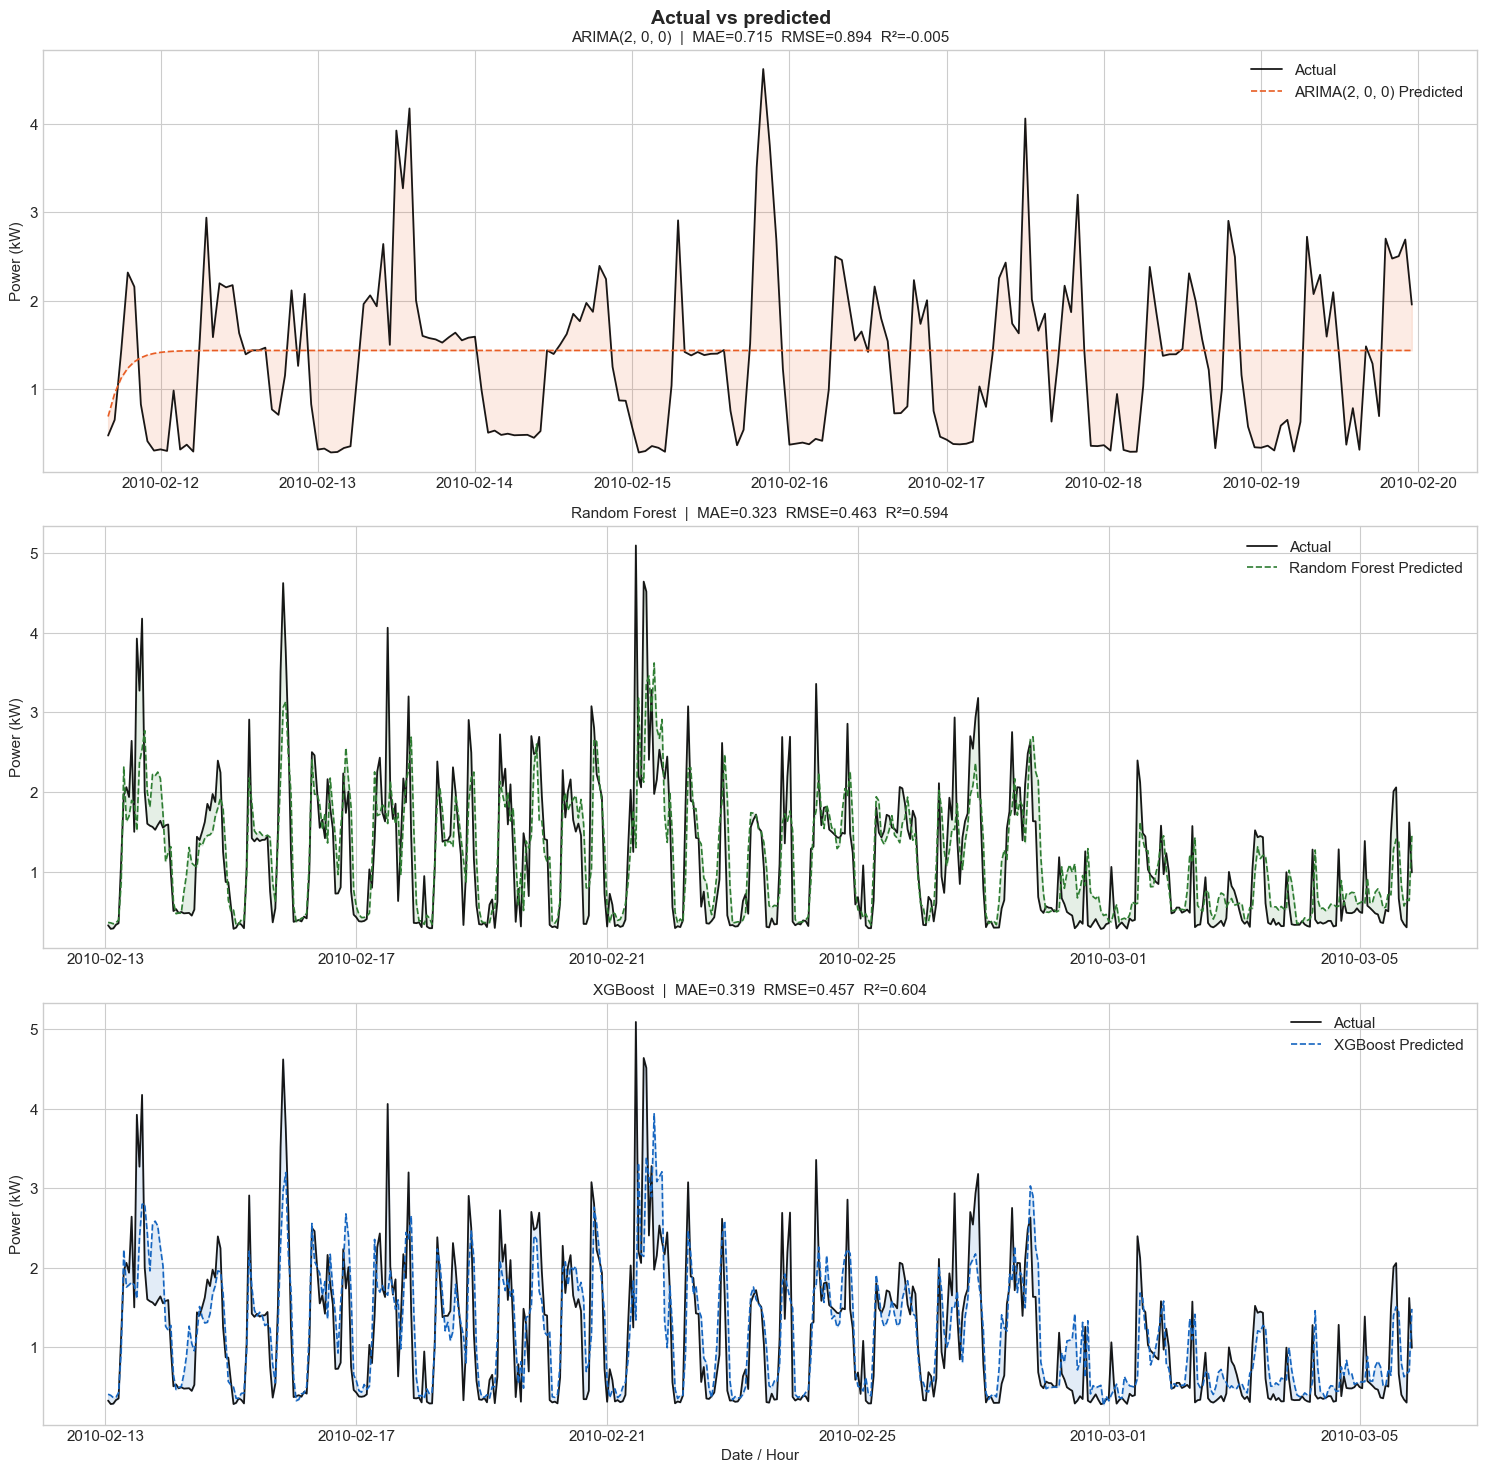

In [43]:
#15 Prediction vs Actual Graph 

n_show =500
n_show_arima = min(n_show, len(test_a))

fig, axes = plt.subplots(3,1,figsize=(15,15) )
fig.suptitle('Actual vs predicted ', fontsize=14 , fontweight='bold')


# ARIMA subplot
ax_arima = axes[0]
actual_a = test_a.iloc[:n_show]
pred_a   = pred_arima.iloc[:n_show]
ax_arima.plot(actual_a.index, actual_a.values, 
              label='Actual', color='black', linewidth=1.3, alpha=0.9)
ax_arima.plot(pred_a.index, pred_a.values,
              label=f'{arima_label} Predicted', color='#E85D24',
              linewidth=1.2, linestyle='--')
ax_arima.fill_between(actual_a.index, actual_a.values, pred_a.values,
                      alpha=0.12, color='#E85D24')
ax_arima.set_title(
    f'{arima_label}  |  MAE={mae_arima:.3f}  RMSE={rmse_arima:.3f}  R²={r2_arima:.3f}',
    fontsize=11)
ax_arima.set_ylabel('Power (kW)')
ax_arima.legend(loc='upper right')
 
# Random Forest subplot
ax_rf = axes[1]
actual_rf = y_test.iloc[:n_show]
pred_rf_s = pred_rf[:n_show]
ax_rf.plot(actual_rf.index, actual_rf.values,
           label='Actual', color='black', linewidth=1.3, alpha=0.9)
ax_rf.plot(actual_rf.index, pred_rf_s,
           label='Random Forest Predicted', color='#2E7D32',
           linewidth=1.2, linestyle='--')
ax_rf.fill_between(actual_rf.index, actual_rf.values, pred_rf_s,
                   alpha=0.12, color='#2E7D32')
ax_rf.set_title(
    f'Random Forest  |  MAE={mae_rf:.3f}  RMSE={rmse_rf:.3f}  R²={r2_rf:.3f}',
    fontsize=11)
ax_rf.set_ylabel('Power (kW)')
ax_rf.legend(loc='upper right')
 
# XGBoost subplot
ax_xgb = axes[2]
pred_xgb_s = pred_xgb[:n_show]
ax_xgb.plot(actual_rf.index, actual_rf.values,
            label='Actual', color='black', linewidth=1.3, alpha=0.9)
ax_xgb.plot(actual_rf.index, pred_xgb_s,
            label='XGBoost Predicted', color='#1565C0',
            linewidth=1.2, linestyle='--')
ax_xgb.fill_between(actual_rf.index, actual_rf.values, pred_xgb_s,
                    alpha=0.12, color='#1565C0')
ax_xgb.set_title(
    f'XGBoost  |  MAE={mae_xgb:.3f}  RMSE={rmse_xgb:.3f}  R²={r2_xgb:.3f}',
    fontsize=11)
ax_xgb.set_ylabel('Power (kW)')
ax_xgb.set_xlabel('Date / Hour')
ax_xgb.legend(loc='upper right')
 
plt.tight_layout()
plt.savefig('predictions_vs_actual', dpi=150, bbox_inches='tight')
plt.show()
 



             


